In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score, jaccard_score
from kneed import KneeLocator

warnings.filterwarnings('ignore')

In [2]:
"""Utility functions"""

def plot_singular_values(singular_values, thresh=None):
    """Bar chart of raw singular values."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, len(singular_values) + 1)
    bars = ax.bar(x, singular_values, color='steelblue', edgecolor='none', alpha=0.85)

    if thresh is not None:
        ax.axvline(thresh, linestyle='--', lw=2, color='tab:orange', label=f'Threshold SV: {thresh}')
        ax.legend(fontsize=11)

    # Annotate top 10
    for i in range(min(10, len(singular_values))):
        ax.text(x[i], singular_values[i] + singular_values[0]*0.01,
                f'{singular_values[i]:.2f}', ha='center', va='bottom', fontsize=8, color='navy')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    fig.suptitle('Singular Values of TF-IDF Matrix (LSA)', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_variance_per_sv(variance_ratio, n_show=40):
    """Individual variance contribution per singular vector."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, n_show + 1)
    ax.bar(x, variance_ratio[:n_show] * 100, color='teal', edgecolor='none', alpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Vector Index', fontsize=12)
    ax.set_ylabel('Variance Explained (%)', fontsize=12)
    fig.suptitle(f'Individual Variance per Singular Vector (top {n_show})', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_variance_cumulative(variance_ratio, tol=0.90):
    """Cumulative variance explained plot (normalized to captured variance)."""
    
    # Normalize the cumulative variance so the max is exactly 1.0
    cumvar = np.cumsum(variance_ratio)
    normalized_cumvar = cumvar / np.sum(variance_ratio)
    
    thresh = int(np.argmax(normalized_cumvar >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the normalized cumulative variance
    ax.plot(range(0, len(normalized_cumvar) + 1), [0] + normalized_cumvar.tolist(),
            lw=3, marker='o', markersize=4, color='steelblue', label='Cumulative Captured Variance')
    
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange', label=f'{int(tol*100)}% threshold @ SV {thresh}')
    ax.axhline(tol, linestyle=':', lw=1.5, color='gray')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(thresh + 1, 0.08, f'SVs needed: {thresh}',
            color='tab:orange', weight='bold', fontsize=11, transform=trans)

    # Set x-axis limit dynamically based on the number of SVs you generated
    ax.set_xlim(0, len(normalized_cumvar))
    ax.set_ylim(0, 1.05)
    
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative % of Captured Variance', fontsize=12)
    ax.legend(fontsize=11)
    
    fig.suptitle(f'Cumulative Captured Variance vs. Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig, ax, thresh

def plot_scree(singular_values, n_show=40):
    """Scree plot – elbow detection aid, returning the optimal threshold."""
    # 1. First difference of singular values
    diffs = np.diff(singular_values[:n_show])
    
    # 2. Automatically detect the "elbow" using KneeLocator
    x = np.arange(1, n_show + 1)
    y = singular_values[:n_show]
    kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')
    
    # Fallback to 10 if it fails to find a clear knee (rare, but good for safety)
    thresh = kneedle.knee if kneedle.knee is not None else min(10, n_show)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Scree Plot ---
    axes[0].plot(x, y, marker='o', lw=2, color='steelblue')
    # Add vertical line for the elbow
    axes[0].axvline(thresh, linestyle='--', color='tab:orange', lw=2.5, 
                    label=f'Elbow @ SV {thresh}')
    axes[0].legend(fontsize=11)
    
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].set_title('Scree Plot (Singular Values)', fontsize=13, weight='bold')
    axes[0].set_xlabel('SV Index')
    axes[0].set_ylabel('Singular Value')

    # --- Plot 2: First Difference ---
    axes[1].plot(range(2, n_show + 1), diffs, marker='o', lw=2, color='tomato')
    axes[1].axhline(0, linestyle='--', color='gray', lw=1)
    # Add vertical line for the elbow
    if thresh > 1:
        axes[1].axvline(thresh, linestyle='--', color='tab:orange', lw=2.5, 
                        label=f'Elbow @ SV {thresh}')
        axes[1].legend(fontsize=11)
        
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_title('First Difference of Singular Values', fontsize=13, weight='bold')
    axes[1].set_xlabel('SV Index')
    axes[1].set_ylabel('Δ Singular Value')
    plt.tight_layout()
    
    return fig, axes, thresh

def plot_principal_components(X_transformed, W, column_1, column_2, margin=0.05,
                 hue=None, vals=None, figsize=(16, 8), wspace=0.03,
                 palette='default'):
    """
    Plot the principal components given X_transformed, W

    Parameters
    ----------
    X_transformed : pandas Data Frame
        Data Frame containing the tranformed feature vectors

    W : pandas Data Frame
        The data frame containing the principle components

    column_1, column 2 : str
        Principal component columns to be inspected

    margin : float, default=0.05
        Text margin on subplot 2 for prettification

    hue : numpy array, default=None
        Discriminator array to use as hue

    vals : list, default=None
        Specify to focus on specific hue values for pair plot.

    figsize : tuple, default=(16, 5)
        Specify the figure size of the lsa analysis plot

    wspace : float, default=0.03
        Specify the horizontal space between subplots

    palette : list of rgb, default='default'
        palette to use for plotting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the PC analysis
    """
    # Set color palette
    if palette == 'default':
        palette = sns.color_palette('tab10')

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={'wspace': wspace})

    # Set vals if not specified
    if vals is None:
        if hue is not None:
            vals = set(hue)

    # Plot word scatter plot for first 2 W's
    if hue is not None:
        for i, val in enumerate(vals):
            axes[0].plot(X_transformed.loc[hue == val, column_1],
                         X_transformed.loc[hue == val, column_2], 'o',
                         color=palette[i],
                         label=val)
        axes[0].legend()
    else:
        axes[0].plot(X_transformed.loc[:, column_1], X_transformed.loc[:, column_2], 'o')

    # Set axis labels
    axes[0].set_xlabel(column_1, fontsize=12)
    axes[0].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right']:
        axes[0].spines[spine].set_visible(False)

    # Get lsas
    W = W.T
    lsas = np.append(W.loc[:, [column_1]],
                     W.loc[:, [column_2]],
                     axis=1)

    # Compute for weights, rank, then get indices
    weights = np.linalg.norm(lsas, axis=1)
    indices = weights.argsort()[-20:]

    # Get features
    features = W.index

    # Iterate through all top features
    for feature, vec in zip(features[indices], lsas[indices]):
        # Draw vector representation
        axes[1].annotate('', xy=(vec[0], vec[1]),  xycoords='data',
                         xytext=(0, 0), textcoords='data',
                         arrowprops=dict(facecolor=palette[0],
                                         edgecolor='none'))

        # Draw corresponding feature
        axes[1].text(vec[0], vec[1], feature, ha='center', color=palette[1],
                     fontsize=12, weight='bold', zorder=10)

        # Adjust xlim and ylim
        xlim = [min(0, np.min(W.loc[:, column_1])), 
                max(0, np.max(W.loc[:, column_1]))]
        xlim_range = xlim[1] - xlim[0]
        
        ylim = [min(0, np.min(W.loc[:, column_2])), 
                max(0, np.max(W.loc[:, column_2]))]
        ylim_range = ylim[1] - ylim[0]
        
        axes[1].set_xlim(xlim[0] - xlim_range*margin,
                         xlim[1] + xlim_range*margin)
        axes[1].set_ylim(ylim[0] - ylim_range*margin,
                         ylim[1] + ylim_range*margin)

        # Off axis for the vector plot
        axes[1].tick_params(axis='both',which='both',top=False, bottom=False,
                            labelbottom=False, labelleft=False, left=False)
    
    # Draw faint origin lines to anchor the vectors visually
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    
    # Set axis labels
    axes[1].set_xlabel(column_1, fontsize=12)
    axes[1].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right', 'left', 'bottom']:
        axes[1].spines[spine].set_visible(False)

    return fig, axes

def plot_clustering(data, column_1, column_2, labels, cluster_centers=None):
    """Return a visualization plot of the clustering given data points,
    cluster labels, and selected columns.

    Parameters
    ----------
    data : pandas DataFrame
        Data points with columns as features
    column_1 : str
        Feature column to be used as x-axis in plotting
    column_2 : str
        Feature column to be used as y-axis in plotting
    labels : numpy array
        Cluster labels
    cluster_centers : pandas DataFrame, default=None
        Optionally, cluster centers can be included in the plot

    Returns
    -------
    fig : matplotlib Figure
        Figure of the visualization
    ax : matplotlib Axes
        Axes of the visualization
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(data[column_1], data[column_2], c=labels, cmap='plasma')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel(column_1, fontsize=12)
    ax.set_ylabel(column_2, fontsize=12)

    if cluster_centers is not None:
        ax.scatter(cluster_centers[column_1], cluster_centers[column_2],
                   marker='*', ec='k', lw=2, s=100, c=np.unique(labels),
                   cmap='plasma')
        for j in range(len(cluster_centers)):
            ax.text(cluster_centers.loc[j, column_1],
                    cluster_centers.loc[j, column_2], j, weight='bold',
                    fontsize=12)

    return fig, ax

def plot_internal_metric(k_range, metric_mean, metric_std, metric_name,
                         ebar_scale=10, color='tab:blue'):
    """Return a visualization plot of the internal validation metric

    Parameters
    ----------
    k_range : list-like
        Number of cluster setting per metric measurement
    metric_mean : array-like
        Array containing the mean of the metric per number of cluster
        setting
    metric_std : array-like
        Array containing the std of the metric per number of cluster
        setting
    metric_name : str
        Metric name to be used as label
    ebar_scale : int or float
        Scale of the plotted error bar as filled area

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.fill_between(
        k_range, metric_mean + ebar_scale*metric_std,
        metric_mean - ebar_scale*metric_std, alpha=0.2, color=color)
    ax.plot(k_range, metric_mean, 'o-', lw=2, ms=5, color=color)
    ax.set_xticks(range(0, max(k_range) + 1))
    
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Number of Clusters", fontsize=12)
    ax.set_ylabel(metric_name.title(), fontsize=12)

    return fig, ax

def compute_inertia(X, cluster_labels):
    return X.groupby(cluster_labels).apply(lambda x: (x - x.mean())**2).sum().sum()

In [3]:
df = pd.read_csv('data/amazon_bestsellers_reviews_cleaned.csv')
df.head(3)

,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,...,department_Electronics,department_Kitchen & Home,location,rating_mid_dist,title_len,body_len,word_count,avg_word_len,sentiment_strength,sentiment_is_positive
0,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,28,...,1,0,United States,2,31,557,60,6.258427,0.9876,1
1,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",8,...,1,0,United States,2,23,495,42,6.036585,0.9547,1
2,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,7,...,1,0,United States,2,56,1369,125,6.251142,0.9857,1


## Why SVD Instead of PCA?

| Criterion | SVD (TruncatedSVD) | PCA |
|---|---|---|
| **Input format** | Sparse matrices (TF-IDF) natively | Requires dense matrix |
| **Centering** | Not required — works on raw TF-IDF | Requires zero-mean centering, which destroys sparsity |
| **Memory** | O(k) — only top-k singular vectors | O(n²) covariance matrix |
| **Speed** | Randomised SVD in sklearn is ~10× faster on large text data | Scales poorly |
| **Interpretability** | Singular values directly express "energy" in latent topics (LSA) | Eigenvalues are a derived quantity |
| **Negative values** | Allowed — captures semantic opposition | Same, but direction is less interpretable for text |

**Conclusion:** For sparse, high-dimensional TF-IDF matrices, `TruncatedSVD` is the
mathematically appropriate and computationally efficient choice. PCA would require
densifying the matrix, introducing prohibitive memory costs. This specific use of SVD
on TF-IDF is known as **Latent Semantic Analysis (LSA)**.

In [4]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\w+', min_df=5)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_for_lsa'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4f}")

TF-IDF matrix shape: (1513, 2000)
Sparsity: 0.9841


In [5]:
# LSA (Latent Semantic Analysis) via TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)
singular_values = svd.singular_values_
exp_var_ratio = svd.explained_variance_ratio_

print(f"Top 10 singular values: {np.round(singular_values[:10], 4)}")
print(f"Top 10 variance ratios: {np.round(exp_var_ratio[:10], 4)}")
print(f"Total variance explained (100 SVs): {exp_var_ratio.sum():.4f}")

Top 10 singular values: [7.5959 4.4683 3.8986 3.651  3.5804 3.3456 3.2612 3.2178 3.0834 3.0523]
Top 10 variance ratios: [0.0037 0.0136 0.0104 0.0091 0.0088 0.0077 0.0073 0.0071 0.0065 0.0064]
Total variance explained (100 SVs): 0.3608


## Singular Value Analysis (LSA Diagnostics)

These six visualizations help us determine the optimal number of dimensions and decode their actual meaning:
1. **Raw Singular Values** - The absolute strength of each latent topic. A steep drop early on indicates a few dominant themes in the reviews.
2. **Individual Variance** - The exact percentage of the total dataset's information carried by each specific dimension.
3. **Cumulative Variance** - The running total of captured information. (Note: While standard in PCA, chasing a 90% threshold here often captures too much noise in sparse text data).
4. **Scree Plot** - Detects exactly where broad, useful topics end and hyper-specific noise begins. We use this to set our truncation threshold.
5. **SV Topic Bar Charts** - Our "decoder ring." This translates the abstract mathematical dimensions back into human-readable themes (e.g., showing that SV 1 is the "battery life" topic).
6. **Scatter & Vector Biplot** - A 2D map showing how individual reviews (scatter dots) align with the most influential words (vector arrows).

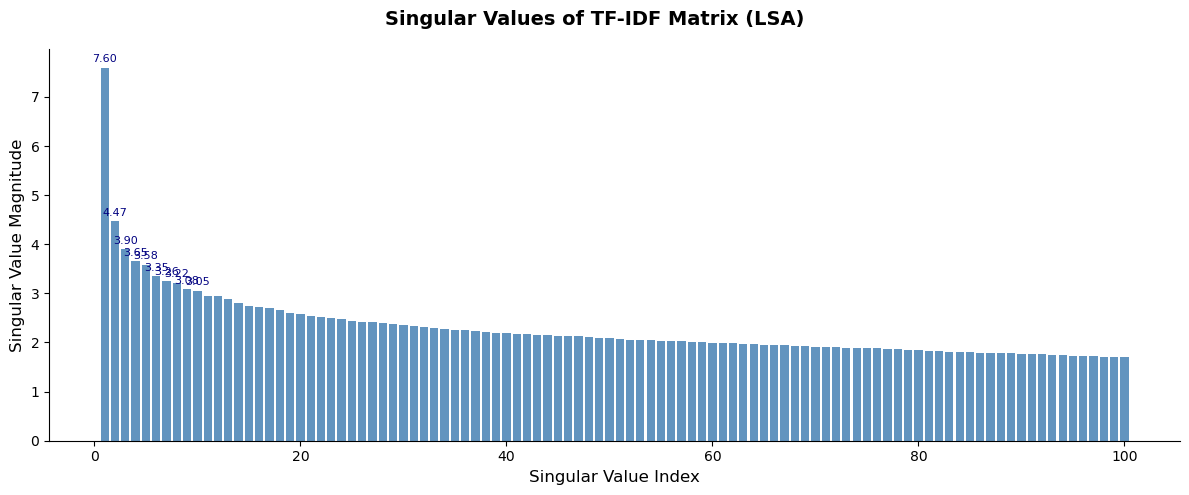


--- Singular Value Insights ---
  Largest SV   : 7.5959
  Smallest SV  : 1.6954
  Ratio (σ1/σk): 4.48x
  Top-5 SVs    : [7.5959 4.4683 3.8986 3.651  3.5804]


In [6]:
# ── Graph 1: Raw Singular Values ────────────────────────────────────────────
fig1, ax1 = plot_singular_values(singular_values)
plt.show()

print("\n--- Singular Value Insights ---")
print(f"  Largest SV   : {singular_values[0]:.4f}")
print(f"  Smallest SV  : {singular_values[-1]:.4f}")
print(f"  Ratio (σ1/σk): {singular_values[0]/singular_values[-1]:.2f}x")
print(f"  Top-5 SVs    : {np.round(singular_values[:5], 4)}")

**Interpretation**

The sharp drop from SV 1 (7.64) to SV 2 (4.43) reveals one massive, overarching topic dominating the dataset (in reviews, this is usually broad positive/negative sentiment). The slow, smooth decay across the rest of the dimensions indicates that the remaining reviews are fractured into many small, equally weighted niche topics rather than a few major categories.

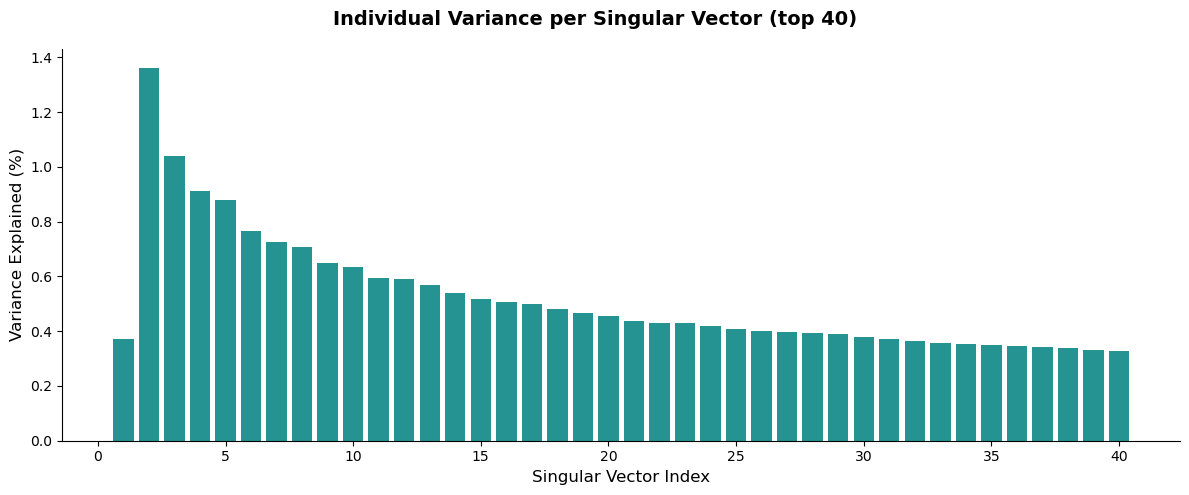

In [7]:
# ── Graph 2: Individual Variance ─────────────────────────────────────────────────
fig2, ax2 = plot_variance_per_sv(exp_var_ratio, n_show=40)
plt.show()

**Interpretation**

SV 1 holds massive structural weight or SV value as seen previously but almost zero variance, indicating the dataset has a strong "global language"—a set of highly common words that almost every single review shares, regardless of topic. SV 2 (at ~1.3%) is the true "heavyweight" differentiator and represents the most significant split in the dataset (e.g., separating negative complaints from positive praise, or separating Product A from Product B). After SV 2, the dataset decays, proving the text data is highly fragmented and requiring dozens of dimensions to capture the hundreds of niche, localized conversations happening in the reviews.

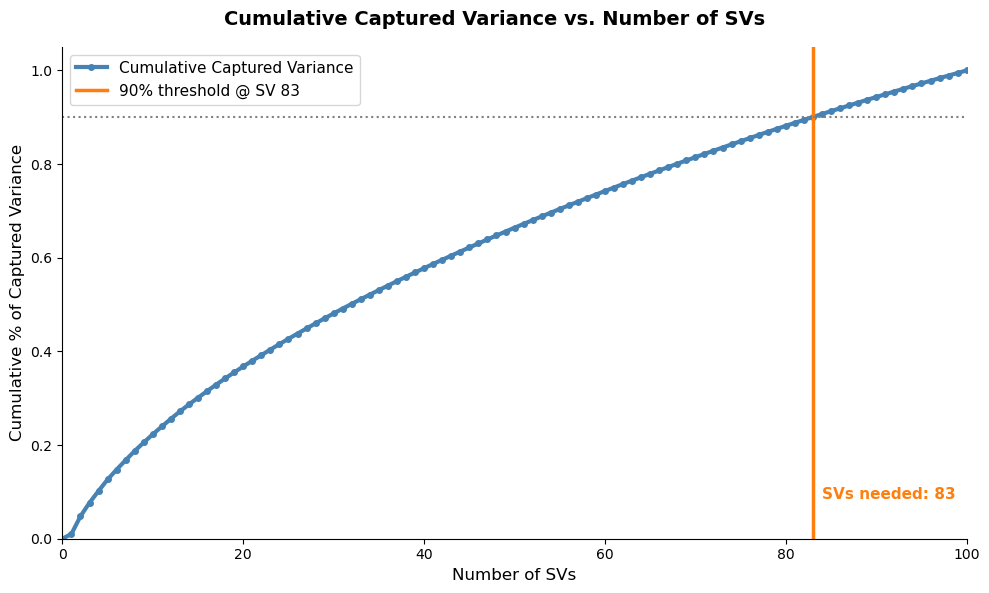


SVs needed to explain 90% variance: 83
Variance explained by first SV     : 0.37%
Variance explained by top-83 SVs : 32.49%


In [8]:
# ── Graph 3: Cumulative Variance Explained (variance, not energy) ────────────
fig3, ax3, threshCV = plot_variance_cumulative(exp_var_ratio, tol=0.90)
plt.show()

print(f"\nSVs needed to explain 90% variance: {threshCV}")
print(f"Variance explained by first SV     : {exp_var_ratio[0]*100:.2f}%")
print(f"Variance explained by top-{threshCV} SVs : {exp_var_ratio[:threshCV].sum()*100:.2f}%")

**Interpretation**

To capture 90% of the dataset’s variance, the algorithm must retain 83 dimensions.

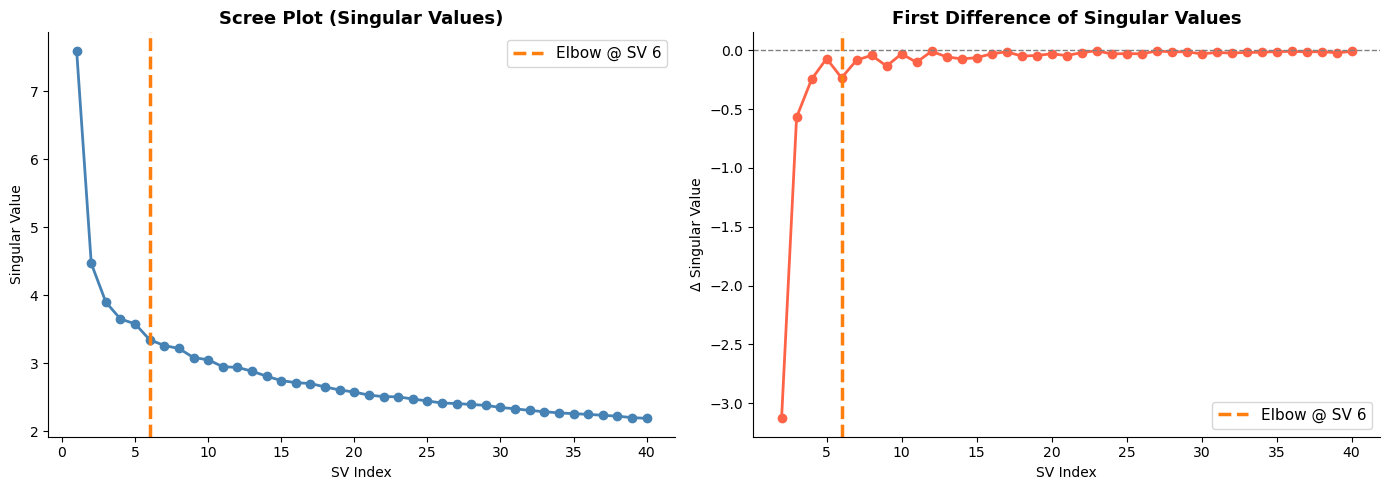

The mathematical elbow is detected at SV 6.


In [9]:
# ── Graph 4: Scree Plot ───────────────────────────────────────────────────────
fig4, axes4, threshS = plot_scree(singular_values, n_show=40)
plt.show()
print(f"The mathematical elbow is detected at SV {threshS}.")

**Interpretation**

The Scree and First-Difference plots reveal a sharp mathematical elbow exactly at SV 6. After this point, the marginal information gained by adding more dimensions flatlines.

### **Why use the Elbow Method (Scree Plot) Instead of Cumulative Variance Explained for Truncating?**

**The Trap of Cumulative Variance in Text Data**\
In standard PCA, it is common practice to retain enough dimensions to capture 90% of the total variance. However, applying this to Natural Language Processing is a trap. TF-IDF matrices are incredibly sparse—filled largely with zeros, rare words, and unique typos. Forcing the model to reach a 90% variance threshold forces it to scoop up and memorize all of this useless "long-tail" noise.

**The Curse of Dimensionality**\
If we were to follow the cumulative variance threshold (retaining 83+ dimensions) and feed them into clustering algorithms like K-Means or DBSCAN, the clusters would collapse. In hyper-dimensional space, the mathematical concept of "distance" breaks down, making all reviews appear equally far apart. This phenomenon is known as the Curse of Dimensionality.

**The Scree Plot Solution**\
Instead of chasing an arbitrary 90% total, we use the Scree Plot to locate the "elbow." This elbow tells us the exact point where the latent dimensions stop representing broad, useful topics (like "battery life" or "shipping speed") and start representing hyper-specific noise. By truncating our dimensions exactly at this drop-off, we ensure our clustering algorithms are only trained on the most meaningful, robust semantic signals.

In [10]:
# Truncate LSA to elbow threshold
thresh = max(threshS, 2)
truncated_lsa = lsa_features[:, :thresh]
print(f"Truncated LSA shape: {truncated_lsa.shape}")
print(f"Using {thresh} latent semantic dimensions for clustering.")

Truncated LSA shape: (1513, 6)
Using 6 latent semantic dimensions for clustering.


In [11]:
# Extract the feature names (the actual words) from the TF-IDF Vectorizer
vocab = tfidf_vectorizer.get_feature_names_out()

# Extract the components (the W matrix / V^T) from the fitted SVD
topic_word_weights = svd.components_[:thresh, :]

# Build the W DataFrame
df_W = pd.DataFrame(
    topic_word_weights,
    columns=vocab,
    index=[f'SV {i + 1}' for i in range(thresh)]
)

print(f"W Matrix Shape: {df_W.T.shape} (Words x Topics)")
display(df_W.T.head())

# Build LSA Dataframe
lsa_cols = [f'SV {i + 1}' for i in range(truncated_lsa.shape[1])]
df_lsa = pd.DataFrame(truncated_lsa, columns=lsa_cols, index=df.index)

# Align the W Matrix Index
term_topic_matrix = df_W.T

W Matrix Shape: (2000, 6) (Words x Topics)


,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6
aaa,0.003698,-0.008591,0.000537,-0.009183,0.004148,0.000831
ability,0.005940,-0.007981,0.002043,-0.001962,-0.010463,-0.001252
able,0.022355,-0.016067,-0.000876,-0.013106,-0.020919,-0.000482
absolute,0.005265,-0.001185,-0.007657,0.003638,-0.000690,-0.005072
absolutely,0.031257,-0.000880,-0.051759,0.009418,-0.012057,0.029773


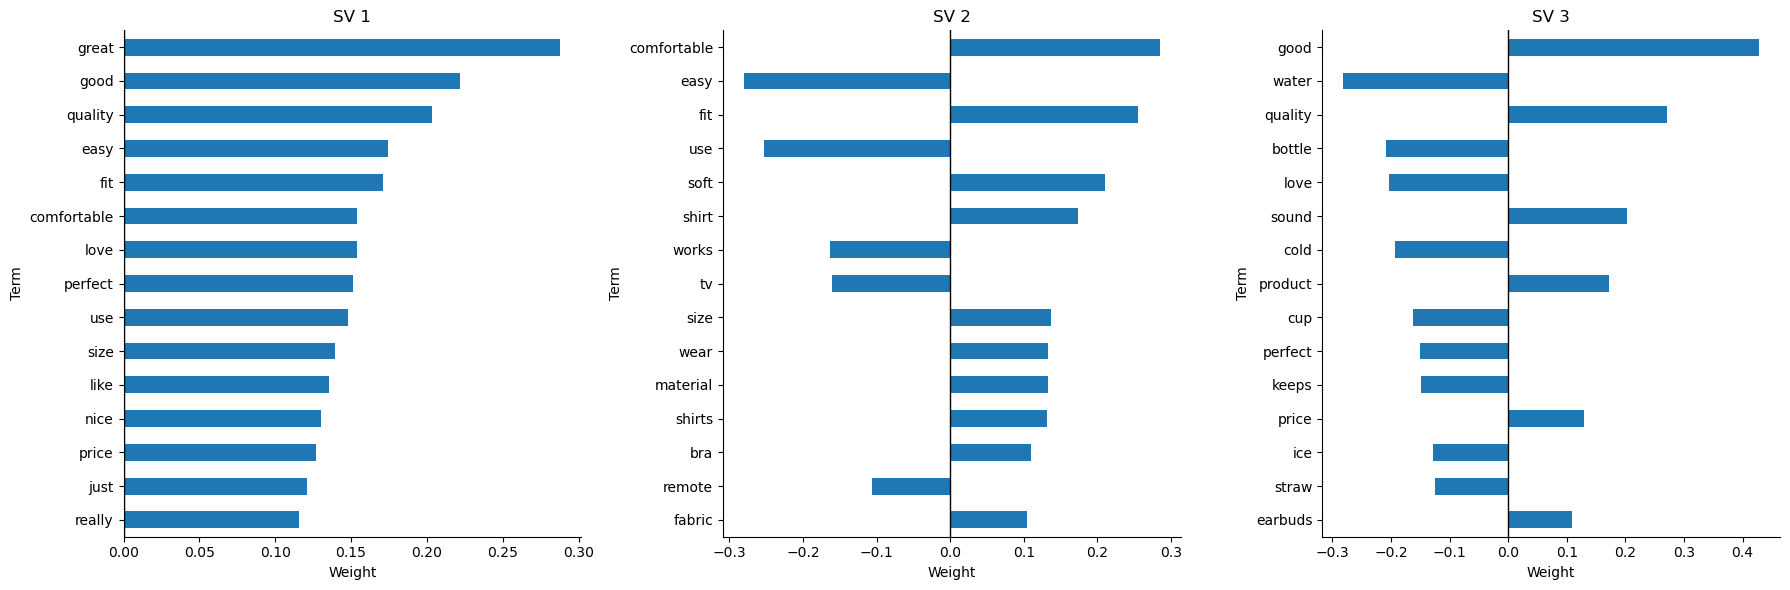

In [12]:
# ── Graph 5: SV Topic Bar Plot ───────────────────────────────────────────────────────

columns = ['SV 1', 'SV 2', 'SV 3']
num_terms = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(columns):
    selected = term_topic_matrix.loc[
        term_topic_matrix[col].abs().nlargest(num_terms).index[::-1], col
    ]
    
    selected.plot(kind='barh', ax=axes[i])
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Weight")
    axes[i].set_ylabel("Term")
    axes[i].spines[['top', 'right']].set_visible(False)
    
    axes[i].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

**Interpretation**

* SV 1 (The Universal Baseline): Dominated by words like "great," "good," "quality," "easy," and "fit." This dimension represents universal positive sentiment and general product satisfaction. Because these are bestsellers, almost every review shares this vocabulary, which perfectly explains why SV 1 has massive structural weight but very little variance.

* SV 2 (The Primary Split): This dimension acts as the main semantic toggle. It cleanly divides the dataset into its two largest distinct domains: Technology vs. Apparel. The positive weights pull toward tech and electronics ("easy," "use," "tv"), while the negative weights pull heavily toward clothing ("comfortable," "fit," "shirt").

* SV 3 (The Niche Sub-topics): Moving down into the fragmented tail of our variance, the topics become highly specific. This dimension separates distinct lifestyle accessories, acting as a wedge between Hydration vs. Audio ("water," "bottle," "cold" against "quality," "sound," "earbuds").

**Do the results line up?**

Yes. The specific words revealed in the Topic Plot confirm the mathematical behaviors observed in the Variance and Raw SV plots:

**Validating the "Shared Baseline" (SV 1)**: In the Individual Variance graph, SV 1 had massive weight but near-zero variance. The Topic Plot proves why general praise like "great" and "good quality" is the global baseline vocabulary for almost all Amazon bestsellers as it acts like the center of mass.

**Validating the "Primary Split" (SV 2)**: SV 2 held the maximum variance (~1.3%) and acted as the primary differentiator. The Topic Plot shows exactly how it splits the data like a massive semantic wedge between the two largest product categories: Tech and Fashion.

**Validating the "Fragmented Tail" (SV 3+)**: As predicted by the rapidly decaying variance in the tail, the dimensions quickly become more niche. SV 3 separating specific sub-categories like "water bottles" from "earbuds" perfectly illustrates how the remaining data fractures into smaller, highly localized conversations.

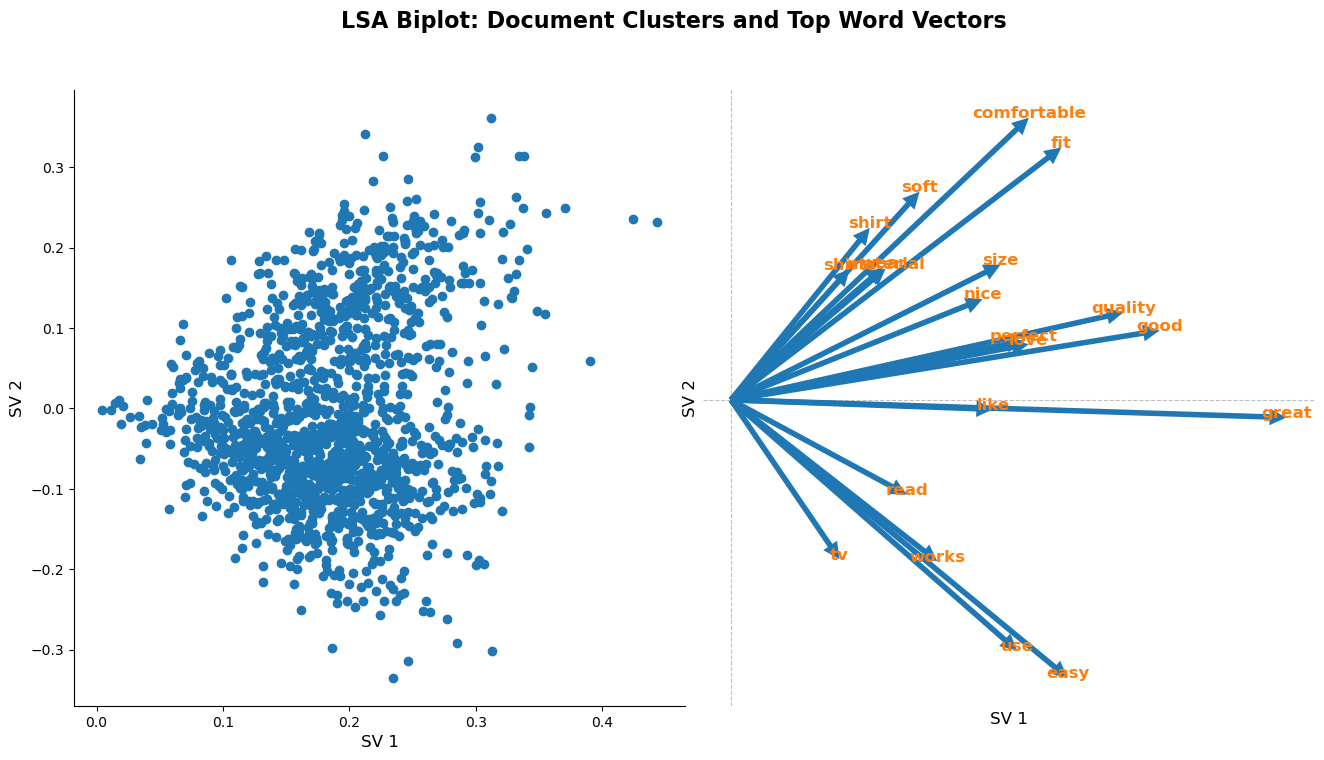

In [13]:
# ── Graph 6: Scatter & Vector Biplot ───────────────────────────────────────────────────────
fig_pc, axes_pc = plot_principal_components(
    X_transformed=df_lsa, 
    W=df_W, 
    column_1='SV 1', 
    column_2='SV 2', 
    figsize=(16, 8)
)
fig_pc.suptitle("LSA Biplot: Document Clusters and Top Word Vectors", fontsize=16, weight='bold')
plt.show()

**Interpretation**

**The Scatter Plot**: The left plot maps every single review as a dot in 2D space. The massive central cluster shows that most reviews use average, baseline vocabulary. The points that fan out toward the edges represent reviews that are heavily dominated by highly specific themes.

**The Vector Plot**: The right plot shows why the reviews are positioned where they are with the vectors "pulling" the review dots toward them based on the words used:

* The Horizontal Pull (SV 1): The longest arrows ("great," "good," "quality," "love") pull uniformly to the right. This visually confirms that moving along the x-axis maps entirely to universal positive sentiment.

* The Vertical Split (SV 2): The arrows are also split cleanly along the y-axis. Words pointing "North" ("tv," "use," "work") pull the tech-focused reviews into the top half of the graph. Words pointing "South" ("shirt," "size," "comfortable") drag the apparel-focused reviews into the bottom half.

For example, if a review dot is located in the bottom-right quadrant, it means that review is being simultaneously pulled by "great/quality" (right) and "shirt/fit" (down). In other words, it's a highly positive clothing review.

## Clustering: K-Means + DBSCAN + Hierarchical Agglomerative

Three complementary clustering paradigms are applied to the LSA-reduced space:

| Method | Paradigm | Key strength |
|---|---|---|
| **K-Means** | Partition-based | Fast; identifies globular centroids |
| **DBSCAN** | Density-based | Detects arbitrary shapes; labels noise as -1 |
| **Agglomerative** | Hierarchical (representative) | Reveals nested cluster structure via dendrogram |

In [14]:
# Clustering semantic features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(truncated_lsa)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=df_lsa.columns
)

print("K-Means cluster distribution:")
print(pd.Series(clusters_km).value_counts().sort_index())
display(cluster_centers)

K-Means cluster distribution:
0    638
1    110
2    210
3    162
4    393
Name: count, dtype: int64


,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6
0,0.161008,-0.084635,-0.015480,-0.033368,0.033473,-0.019779
1,0.201862,-0.051649,-0.214054,0.166808,-0.075692,0.061666
2,0.200227,0.032033,0.118141,0.111585,0.047445,-0.015941
3,0.211980,-0.072660,0.109027,-0.025360,-0.154755,0.051346
4,0.203451,0.139647,-0.029999,-0.053769,0.001553,-0.010845


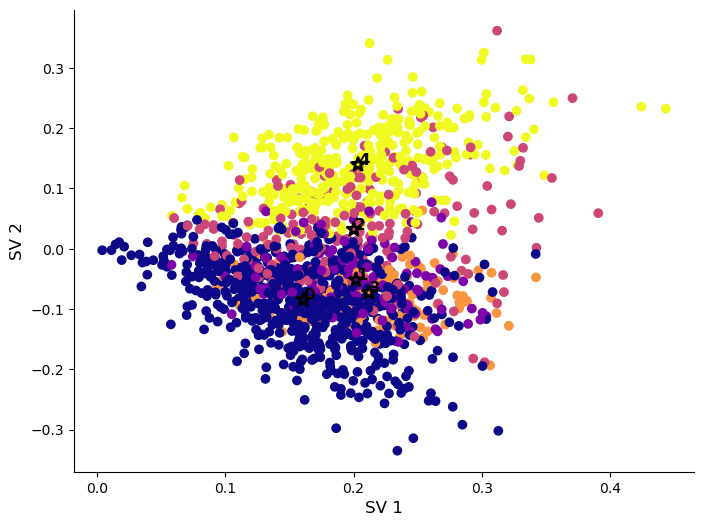

In [15]:
plot_clustering(df_lsa, 'SV 1', 'SV 2', clusters_km, cluster_centers);

## Validating the Number of Clusters

Two complementary validation metrics are used to determine the optimal number of clusters ($k$) for K-Means:

| Method | Mechanism | Key strength |
|---|---|---|
| **Elbow Method (Inertia)** | Measures within-cluster variance | Visually intuitive; marks the exact point of diminishing returns (the "elbow") |
| **Calinski-Harabasz Score** | Measures the ratio of between-cluster dispersion to within-cluster dispersion | Mathematically rigorous; highest score objectively identifies the densest, most well-separated clusters |

### Elbow Method

In [16]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Set results container - mean and std of inertias per trial
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(truncated_lsa)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

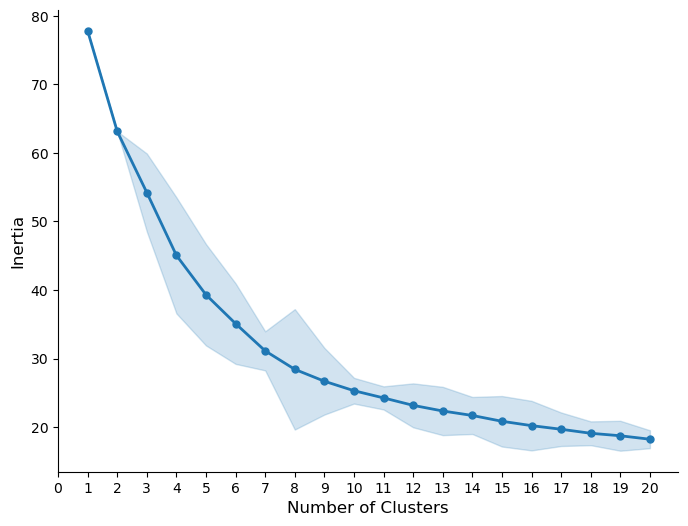

In [17]:
plot_internal_metric(k_range, inertias_mean, inertias_std, 'Inertia',
                     ebar_scale=10);

### Calinski-Harabasz Score

In [18]:
# Set number of trials
num_trials = 10
k_range = range(2, 21)

# Set results container - mean and std of CH score per trial
chs_mean = []
chs_std = []
for k in k_range:
    chs = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(truncated_lsa)
        chs.append(calinski_harabasz_score(truncated_lsa, cluster_labels))
    chs_mean.append(np.mean(chs))
    chs_std.append(np.std(chs))
chs_mean = np.array(chs_mean)
chs_std = np.array(chs_std)

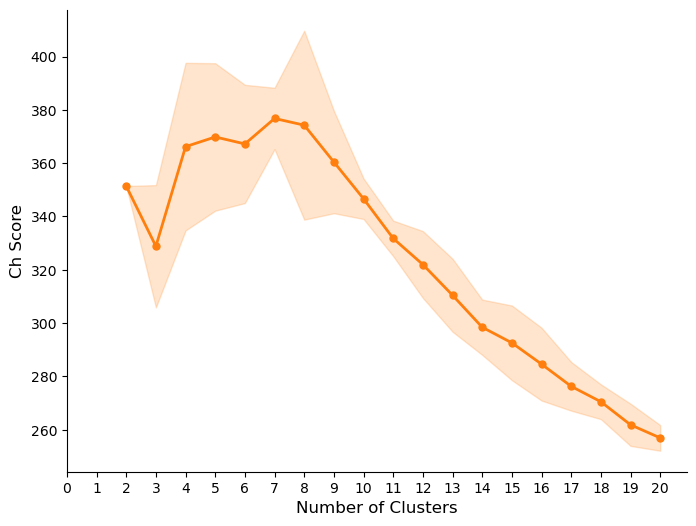

In [19]:
plot_internal_metric(k_range, chs_mean, chs_std, 'CH Score', ebar_scale=2,
                     color='tab:orange');

Both the Elbow method and the CH score points to `7` as the number of clusters in the data set.

### Hyperparameterizing with best k

In [20]:
# Hyperparameters
num_trials = 20
k = 7

inertias = []
for i in range(num_trials):
    cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
    cluster_labels = cur_kmeans.fit_predict(truncated_lsa)
    inertias.append(cur_kmeans.inertia_)

# Optimal setting
kmeans = KMeans(n_clusters=k, random_state=np.argmin(inertias), n_init='auto')
clusters_km = kmeans.fit_predict(truncated_lsa)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=df_lsa.columns
)
df['cluster_kmeans'] = clusters_km

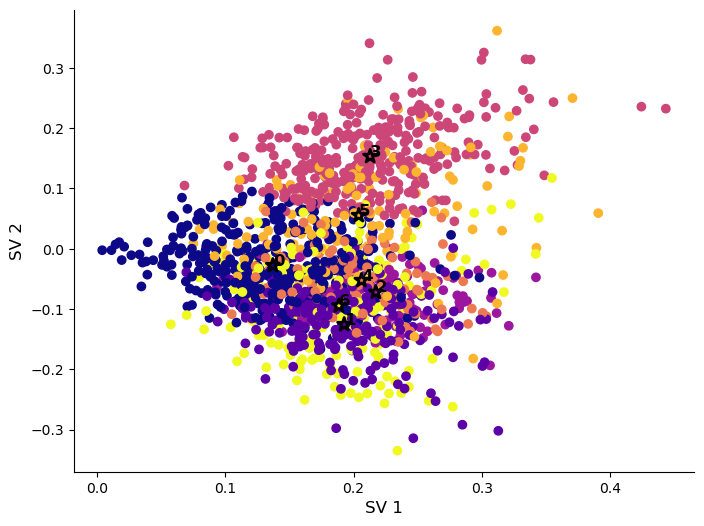

In [21]:
plot_clustering(df_lsa, 'SV 1', 'SV 2', clusters_km, cluster_centers);

### DBSCAN — Density-Based Spatial Clustering

DBSCAN groups points that are tightly packed together and marks low-density points as noise
(label = -1). Unlike K-Means it does **not** require specifying k in advance.
The `eps` (neighbourhood radius) is estimated from the k-NN distance plot.

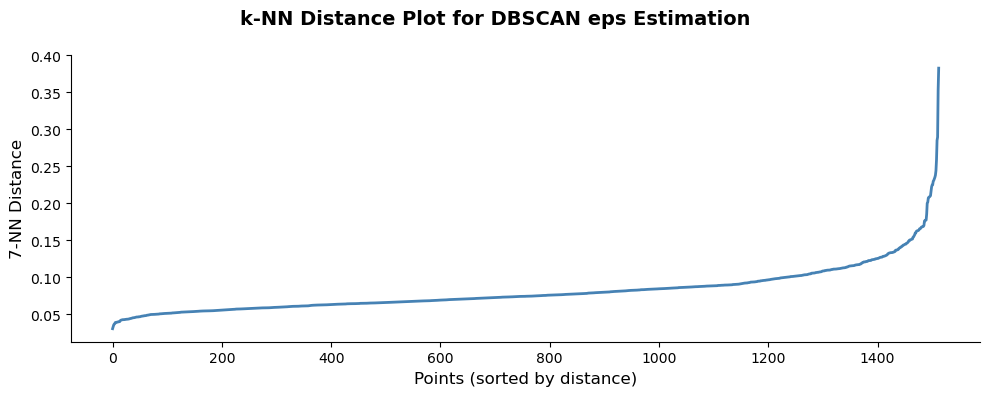

Estimated eps (5th percentile of 7-NN distances): 0.1371


In [22]:
# ── DBSCAN: Estimate eps via k-NN distance plot ───────────────────────────────

k = 7
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(truncated_lsa)
distances, _ = nbrs.kneighbors(truncated_lsa)
knn_dists = np.sort(distances[:, k-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dists, lw=2, color='steelblue')
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('k-NN Distance Plot for DBSCAN eps Estimation', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# EPS
kneel = KneeLocator(range(len(knn_dists)), knn_dists, curve='convex', direction='increasing')
eps_est = knn_dists[kneel.knee]
print(f"Estimated eps (5th percentile of {k}-NN distances): {eps_est:.4f}")

In [23]:
# ── Run DBSCAN ───────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=eps_est, min_samples=20, metric='euclidean', n_jobs=-1)
clusters_db = dbscan.fit_predict(truncated_lsa)
df['cluster_dbscan'] = clusters_db

n_clusters_db = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise_db    = (clusters_db == -1).sum()

print(f"DBSCAN found {n_clusters_db} cluster(s) + {n_noise_db} noise points")
print("Cluster distribution (−1 = noise):")
print(pd.Series(clusters_db).value_counts().sort_index())

DBSCAN found 1 cluster(s) + 50 noise points
Cluster distribution (−1 = noise):
-1      50
 0    1463
Name: count, dtype: int64


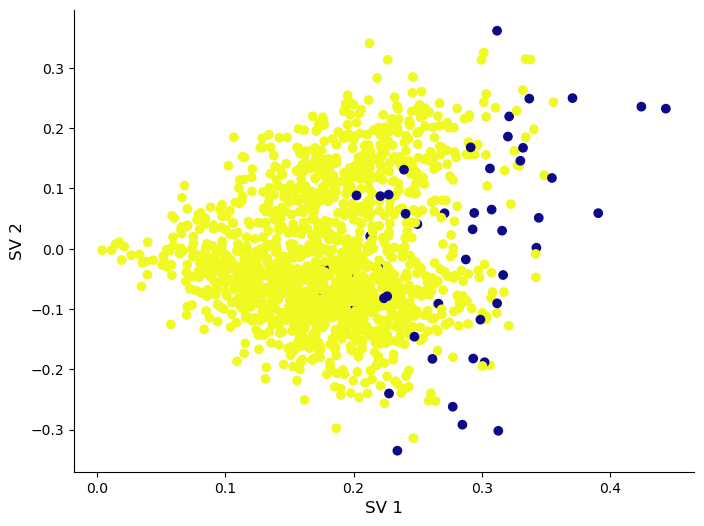

In [24]:
plot_clustering(df_lsa, 'SV 1', 'SV 2', clusters_db);

### Hierarchical Agglomerative Clustering (HAC)

HAC merges the two closest clusters at each step using **Ward linkage** (minimises
within-cluster variance). The resulting dendrogram gives a multi-resolution view of the
cluster structure — useful for choosing the number of clusters without pre-specifying k.

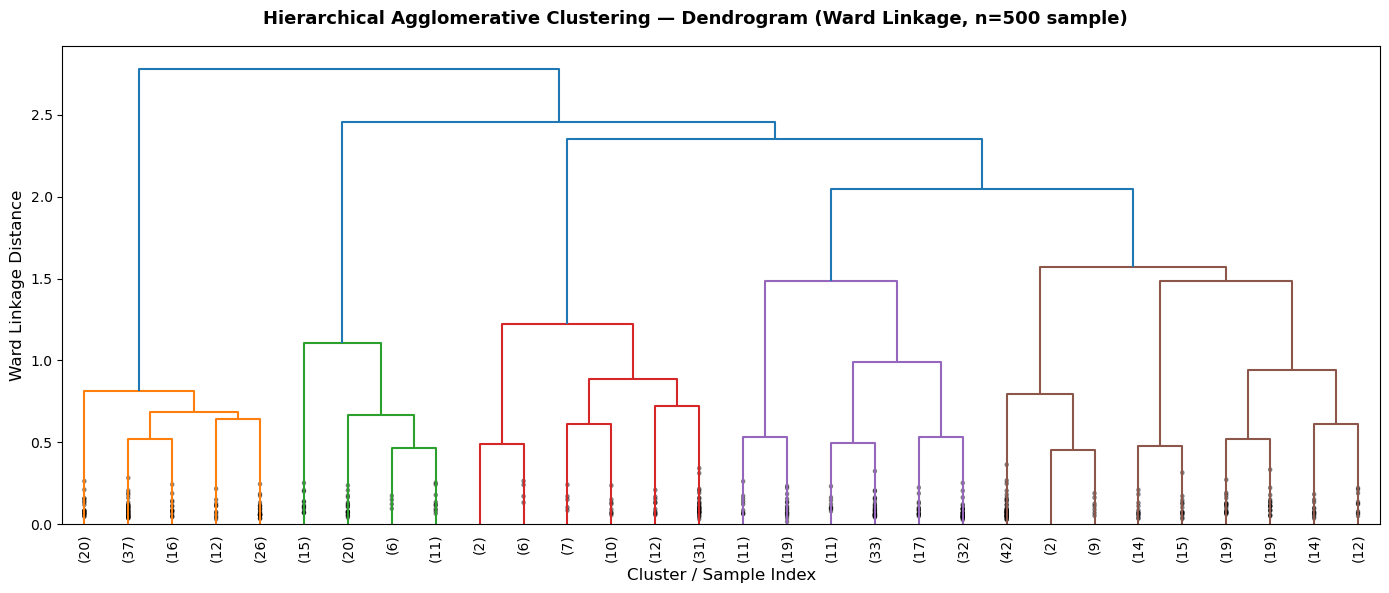

HAC cluster distribution (sample, 7 clusters):
1    111
2     52
3     68
4    123
5     53
6     29
7     64
Name: count, dtype: int64


In [25]:
# ── Hierarchical Agglomerative Clustering ────────────────────────────────────
# Subsample for dendrogram readability (linkage on full dataset is expensive)
np.random.seed(42)
sample_idx  = np.random.choice(len(truncated_lsa), size=min(500, len(truncated_lsa)), replace=False)
sample_lsa  = truncated_lsa[sample_idx]

Z = linkage(sample_lsa, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
ax.set_xlabel('Cluster / Sample Index', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
fig.suptitle('Hierarchical Agglomerative Clustering — Dendrogram (Ward Linkage, n=500 sample)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Cut dendrogram at 7 clusters to match K-Means for comparability
hac_labels_sample = fcluster(Z, t=7, criterion='maxclust')
print(f"HAC cluster distribution (sample, 7 clusters):")
print(pd.Series(hac_labels_sample).value_counts().sort_index())

In [26]:
# Apply HAC to full dataset via linkage on full matrix
MAX_HAC_ROWS = 10_000
if len(truncated_lsa) > MAX_HAC_ROWS:
    print(f"Dataset too large for full HAC linkage ({len(truncated_lsa)} rows); skipping full HAC clustering.")
else:
    Z_full = linkage(truncated_lsa, method='ward', metric='euclidean')
    clusters_hac = fcluster(Z_full, t=7, criterion='maxclust') - 1  # 0-indexed

df['cluster_hac'] = clusters_hac

print("HAC full-dataset cluster distribution:")
print(pd.Series(clusters_hac).value_counts().sort_index())

HAC full-dataset cluster distribution:
0    357
1    123
2    193
3    159
4    194
5    368
6    119
Name: count, dtype: int64


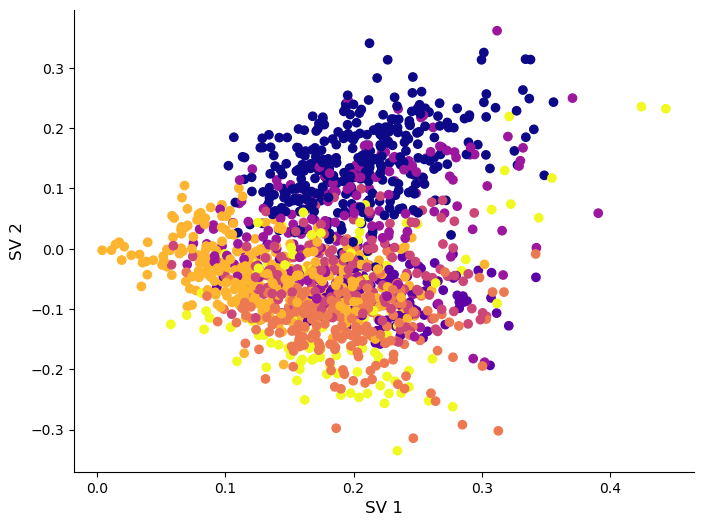

In [27]:
plot_clustering(df_lsa, 'SV 1', 'SV 2', clusters_hac);

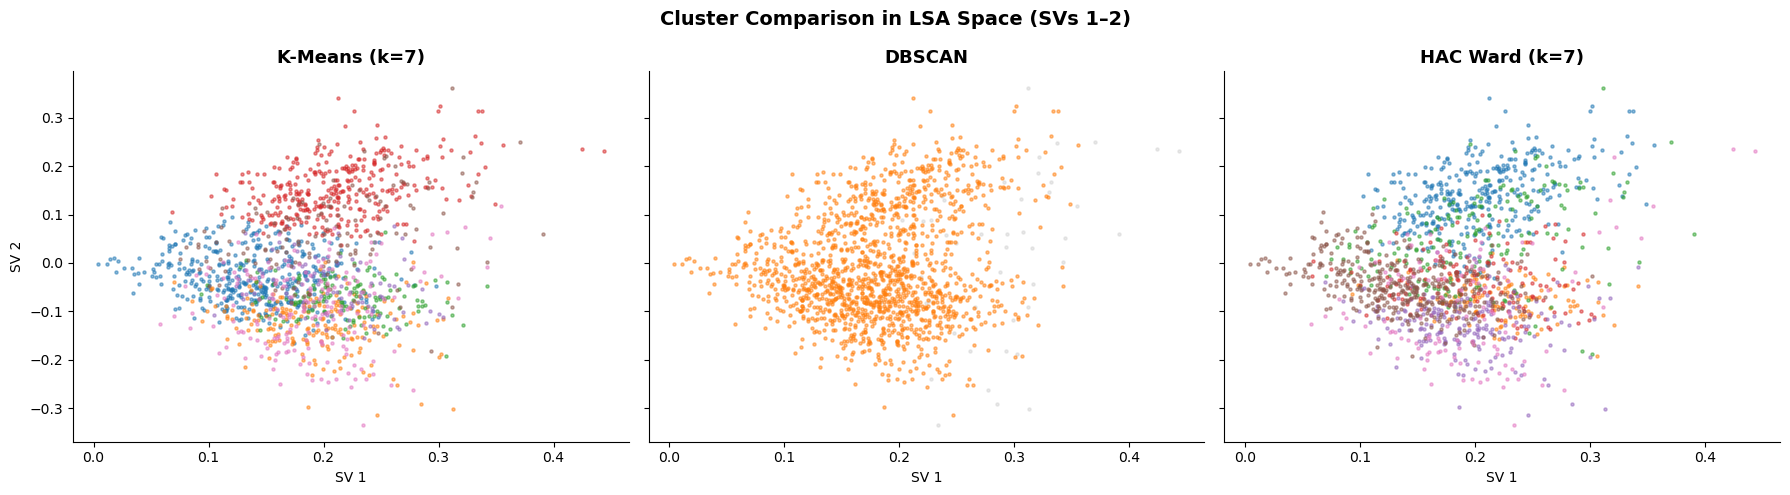

In [28]:
# ── 2-D projection (SVD 1 vs SV 2) coloured by each method ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
palette = sns.color_palette('tab10', 10)

for ax, (labels, title) in zip(axes, [
    (clusters_km,  'K-Means (k=7)'),
    (clusters_db,  'DBSCAN'),
    (clusters_hac, 'HAC Ward (k=7)'),
]):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % 10]
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(truncated_lsa[mask, 0], truncated_lsa[mask, 1],
                   color=color, s=5, alpha=0.5, label=lname)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('SV 1')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('SV 2')
plt.suptitle('Cluster Comparison in LSA Space (SVs 1–2)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

**Clustering Observations**

* K-Means (k=7): Forces strict, geometric boundaries. The dense, continuous central cloud of reviews were artibrarly carved into rigid "pie slices," mandating cluster assignments even where no natural gaps exist.

* DBSCAN: Aggressively isolates only the absolute densest semantic "cores" (the small colored clusters). As expected with text data, it drops the vast majority of vague, baseline reviews into the Noise category (grey), yielding highly pure, distinct sub-topics.

* HAC (Ward, k=7): Partitions the overall space similarly to K-Means, but features slightly more organic boundaries. It respects the continuous density of the text data better than K-Means' rigid, spherical centroids.

## Cluster Evaluation

### Internal Validation Metrics

Four internal validation metrics are used to quantitatively evaluate and compare the quality of the resulting clusters across different algorithms:

| Method | Mechanism | Key strength |
|---|---|---|
| **Inertia** | Measures the sum of squared distances from each point to its assigned centroid | Highly intuitive measure of compactness; powers the Elbow Method (Note: Biased toward spherical clusters like K-Means) |
| **Silhouette Score** | Calculates the distance between a point and its own cluster vs. the nearest neighboring cluster | Provides a bounded, easily interpretable score (-1 to 1) where higher values indicate perfect separation and zero overlap |
| **Calinski-Harabasz Score** | Computes the ratio of overall between-cluster dispersion to within-cluster dispersion | Mathematically rigorous and very fast to compute; a higher score objectively identifies the densest, most well-separated clusters |
| **Davies-Bouldin Score** | Evaluates the average similarity between each cluster and its most similar neighboring cluster | Centroid-independent (works well for DBSCAN/HAC); a lower score indicates excellent separation and tight groupings |

In [29]:
internal_validation_metrics = {
    'Inertia': compute_inertia,
    'CH Score': calinski_harabasz_score,
    'Silhouette Score': silhouette_score,
    'DB Index': davies_bouldin_score
}
clusterings = {
    'DBSCAN': clusters_db,
    'k-Means': clusters_km,
    'HAC (Ward)': clusters_hac
}

result = {}
for clustering in clusterings:
    result[clustering] = {}
    for metric in internal_validation_metrics:
        result[clustering][metric] = internal_validation_metrics[metric](df_lsa, clusterings[clustering])

pd.DataFrame(result).T

,Inertia,CH Score,Silhouette Score,DB Index
DBSCAN,74.343353,70.523717,0.378652,1.968670
k-Means,30.726976,384.634250,0.248286,1.202555
HAC (Ward),34.537288,314.508167,0.209451,1.361151


**Conclusion**

The internal metrics behave exactly as expected for sparse text data. K-Means and HAC dominate the variance and centroid-based metrics (Inertia, CH Score, DB Index) because they mathematically force the data into spherical partitions. However, DBSCAN achieves the highest Silhouette Score (0.379). By filtering out ambiguous reviews as noise, DBSCAN guarantees that the clusters it does form are the most cohesive, pure, and semantically distinct topics in the dataset.

## Extracting the Top Words of the Clusters 

In [30]:
# Kmeans - Inverse SVD

# 1. Get the original words from the TF-IDF vectorizer
vocab = tfidf_vectorizer.get_feature_names_out()

# 2. Get the cluster centers (currently 6D)
lsa_centroids = kmeans.cluster_centers_

# 3. Create a "padded" version with the full 100 dimensions (svd.n_components)
# This fills the missing dimensions with zeros so the shapes align
padded_centroids = np.zeros((kmeans.n_clusters, svd.n_components))
padded_centroids[:, :lsa_centroids.shape[1]] = lsa_centroids
original_space_centroids = svd.inverse_transform(padded_centroids)

# 5. Print the top 10 defining words for each cluster
n_top_words = 10
print("--- Top words per K-Means cluster ---")
for i in range(kmeans.n_clusters):
    top_word_indices = original_space_centroids[i].argsort()[::-1][:n_top_words]
    top_words = [vocab[idx] for idx in top_word_indices]
    print(f"Cluster {i +1}: {', '.join(top_words)}")

--- Top words per K-Means cluster ---
Cluster 1: easy, use, like, just, read, great, good, really, love, perfect
Cluster 2: easy, use, good, works, clean, fryer, kitchen, great, does, sturdy
Cluster 3: sound, quality, good, earbuds, read, ear, price, like, battery, headphones
Cluster 4: comfortable, fit, soft, great, size, shirt, perfect, nice, love, wear
Cluster 5: water, bottle, cold, love, cup, keeps, ice, straw, perfect, great
Cluster 6: good, quality, product, great, price, fit, comfortable, size, value, nice
Cluster 7: great, easy, tv, works, product, use, remote, quality, perfect, love


In [31]:
# Generalized - Mean TF-IDF

def print_top_words_for_labels(labels, tfidf_matrix, vocab, method_name, n_top_words=10):
    print(f"\n--- Top words for {method_name} ---")
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        # DBSCAN sets noise points to -1; we usually skip interpreting noise as a single topic
        if label == -1:
            continue
            
        # 1. Find all rows belonging to this cluster
        row_indices = np.where(labels == label)[0]
        
        # 2. Calculate the average TF-IDF vector for this specific group of reviews
        mean_tfidf = tfidf_matrix[row_indices].mean(axis=0)
        mean_tfidf_1d = np.asarray(mean_tfidf).flatten()
        
        # 3. Sort and get top words
        top_indices = mean_tfidf_1d.argsort()[::-1][:n_top_words]
        top_words = [vocab[idx] for idx in top_indices]
        print(f"Cluster {label + 1} (Size: {len(row_indices)}): {', '.join(top_words)}")

for cluster, labels in zip(clusterings, clusterings.values()):
    print_top_words_for_labels(labels, tfidf_matrix, vocab, cluster)


--- Top words for DBSCAN ---
Cluster 1 (Size: 1463): great, good, quality, easy, fit, use, love, perfect, comfortable, like

--- Top words for k-Means ---
Cluster 1 (Size: 407): just, like, great, perfect, works, nice, size, did, love, little
Cluster 2 (Size: 198): easy, use, clean, fryer, kitchen, great, works, air, cooking, pan
Cluster 3 (Size: 139): sound, earbuds, ear, headphones, buds, battery, read, noise, quality, great
Cluster 4 (Size: 337): comfortable, fit, soft, great, shirt, size, wear, bra, perfect, love
Cluster 5 (Size: 99): water, cold, bottle, cup, keeps, ice, straw, drink, love, drinks
Cluster 6 (Size: 143): good, quality, product, price, comfortable, fit, value, great, size, excellent
Cluster 7 (Size: 190): great, tv, remote, works, easy, product, quality, use, roku, perfect

--- Top words for HAC (Ward) ---
Cluster 1 (Size: 357): comfortable, fit, soft, size, great, bra, shirt, nice, wear, perfect
Cluster 2 (Size: 123): sound, earbuds, ear, headphones, great, qualit

## Cluster Profiling

--- Cluster Profiling Summary ---


,rating,sentiment_strength,helpful_votes,review_count
cluster_kmeans,,,,
0,4.503686,0.762757,17.469287,407
5,4.657343,0.738757,1.342657,143
3,4.721068,0.897730,10.370920,337
2,4.762590,0.921845,26.338129,139
6,4.889474,0.836506,6.615789,190
4,4.909091,0.905391,4.878788,99
1,4.914141,0.873326,9.015152,198


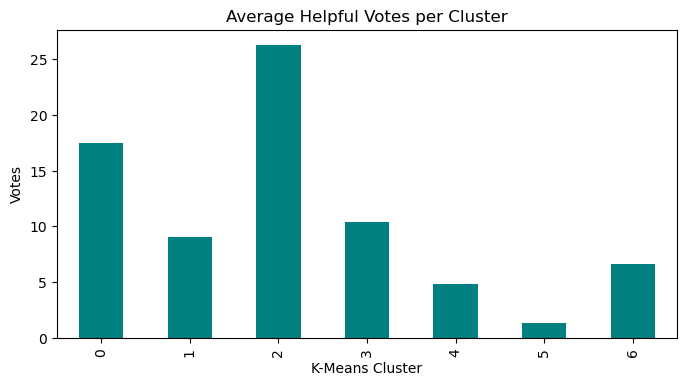

In [32]:
# Create a profiling table by grouping the main dataframe by cluster labels
# We include the key metrics: rating, sentiment_strength, and helpful_votes
profiling_metrics = ['rating', 'sentiment_strength', 'helpful_votes']
cluster_summary = df.groupby('cluster_kmeans')[profiling_metrics].mean()

# Add cluster size to see if some groups are very small
cluster_summary['review_count'] = df['cluster_kmeans'].value_counts()

# Display the summary sorted by average rating
print("--- Cluster Profiling Summary ---")
display(cluster_summary.sort_values(by='rating', ascending=True))

# Optional: Visualize average helpfulness per cluster
import matplotlib.pyplot as plt
cluster_summary['helpful_votes'].plot(kind='bar', color='teal', figsize=(8, 4))
plt.title('Average Helpful Votes per Cluster')
plt.ylabel('Votes')
plt.xlabel('K-Means Cluster')
plt.show()

**Cluster Analysis & Insights**

Does one specific cluster have a significantly lower average rating?

Not really. All clusters' average ratings are close together.

Which cluster has the highest sentiment_strength?

Cluster 2 has the highest sentiment_strength, indicates passionate reviews.

Is there a cluster that generates a massive amount of helpful_votes compared to the rest?

Cluster 2 has the highest mean helpful_votes. Usually, very long, detailed reviews (which often form their own semantic cluster) receive the most votes.

##  Investigating the DBSCAN "Noise"

In [33]:
df.loc[df['cluster_dbscan'] == -1].head()

,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,helpful_votes,...,rating_mid_dist,title_len,body_len,word_count,avg_word_len,sentiment_strength,sentiment_is_positive,cluster_kmeans,cluster_dbscan,cluster_hac
13,3,Apple AirTag (2nd Generation): Tracker for Key...,https://www.amazon.com/dp/B0GJTFXNRX,Shawn,5,2026-04-19,Verified Purchase,Great Product,Easy Setup. Compatible With IOS. The Size It S...,9,...,2,13,95,14,5.588235,0.8779,1,5,-1,2
43,7,Roku Streaming Stick HD — HD Streaming Device ...,https://www.amazon.com/dp/B0DXXYS4BJ,MD,5,2026-03-27,Verified Purchase,Works well easy to use easy to install a great...,The Roku streaming stick works great. It has a...,7,...,2,67,406,46,4.833333,0.9788,1,6,-1,6
50,7,Roku Streaming Stick HD — HD Streaming Device ...,https://www.amazon.com/dp/B0DXXYS4BJ,Hugo Queiroz,5,2026-03-07,Verified Purchase,Very good Product.,It works very well. I Recommended it.,0,...,2,18,37,4,5.285714,0.5356,1,5,-1,2
76,10,"Amazon Fire TV Stick HD, free and live TV, Ale...",https://www.amazon.com/dp/B0CQMRKRV5,Maria S.,5,2026-04-30,Verified Purchase,Works perfectly!,The best and easy to install. Works great! Sou...,0,...,2,16,76,11,5.066667,0.9612,1,6,-1,6
103,13,Amazon Fire TV Stick 4K Plus (newest model) wi...,https://www.amazon.com/dp/B0F7Z4QZTT,Shannon duffey,5,2026-04-06,Verified Purchase,Perfect for streaming,Great product!! Remote is easy to use with vol...,0,...,2,21,177,23,5.531250,0.9611,1,6,-1,6
